In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import shap

C:\Users\noton\anaconda3\envs\env1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv('data/data_DFT.csv')
y = pd.DataFrame(data['Yield'], columns=['Yield'])
X = data.drop(columns=['PC_ID', 'Alc_ID', 'Yield', 'PC_SMILES', 'Alc_SMILES'])
print(X.head())
print('==========(Result)==========')

r2_score = []
rmse_score = []
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=i)
    param = {"min_samples_leaf": [2, 3, 5], "max_depth": [4, 6], "l2_regularization": [0, 0.1, 1]}
    reg = GridSearchCV(HistGradientBoostingRegressor(random_state=0, max_leaf_nodes=5, max_bins=30),
                       param_grid=param, cv=5, n_jobs=12)
    reg.fit(X_train, y_train['Yield'])
    best = reg.best_estimator_
    y_pred1 = best.predict(X_train)
    y_pred2 = best.predict(X_test)
    r2 = metrics.r2_score(y_test, y_pred2)
    rmse = metrics.root_mean_squared_error(y_test, y_pred2)
    print(f'Run{i} R2 (test): {r2:.2f}, RMSE (test): {rmse:.2f}')
    r2_score.append(r2)
    rmse_score.append(rmse)

    PC_HOMO   PC_LUMO   PC_S1  PC_T1_a  PC_%Vbur50  Alc_HOMO  Alc_LUMO  \
0 -9.223168 -0.588574  3.7691    2.606        40.2 -8.938541  0.123538   
1 -9.223168 -0.588574  3.7691    2.606        40.2 -8.906977  1.054154   
2 -9.223168 -0.588574  3.7691    2.606        40.2 -8.360308  0.548846   
3 -9.223168 -0.588574  3.7691    2.606        40.2 -8.668336  1.062317   
4 -9.223168 -0.588574  3.7691    2.606        40.2 -8.231872  1.047351   

      Alc_BDE  
0  110.283966  
1  110.158466  
2  110.164741  
3  110.089441  
4  110.409466  
==========(Result)==========
Run0 R2 (test): 0.75, RMSE (test): 13.56
Run1 R2 (test): 0.74, RMSE (test): 10.57
Run2 R2 (test): 0.84, RMSE (test): 7.51
Run3 R2 (test): 0.82, RMSE (test): 11.41
Run4 R2 (test): 0.88, RMSE (test): 8.56
Run5 R2 (test): 0.80, RMSE (test): 9.34
Run6 R2 (test): 0.85, RMSE (test): 7.70
Run7 R2 (test): 0.70, RMSE (test): 11.30
Run8 R2 (test): 0.83, RMSE (test): 9.16
Run9 R2 (test): 0.71, RMSE (test): 10.63


0.8774566443058842


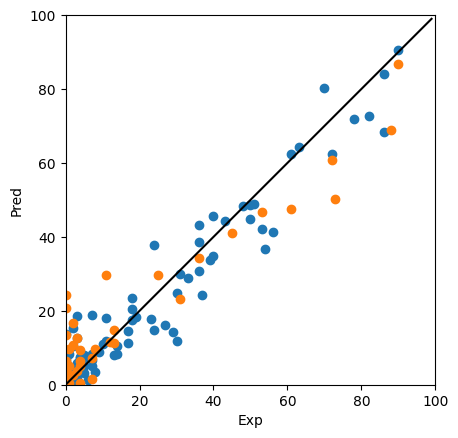

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=4)
param = {"min_samples_leaf": [2, 3, 5], "max_depth": [4, 6], "l2_regularization": [0, 0.1, 1]}
reg = GridSearchCV(HistGradientBoostingRegressor(random_state=0, max_leaf_nodes=5, max_bins=30), param_grid=param, cv=5, n_jobs=12)
reg.fit(X_train, y_train['Yield'])
best = reg.best_estimator_
y_pred1 = best.predict(X_train)
y_pred2 = best.predict(X_test)
print(metrics.r2_score(y_test, y_pred2))

fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(range(0,100), range(0,100), c='black')
plt.scatter(y_train, y_pred1)
plt.scatter(y_test, y_pred2)
plt.xlim(0, 100)
plt.ylim(0, 100)
ax.set_aspect('equal', adjustable='box')
plt.xlabel('Exp')
plt.ylabel('Pred')

fig.savefig('SHAP/result.pdf')

In [4]:
explainer = shap.TreeExplainer(best)
shap_values = explainer(X)

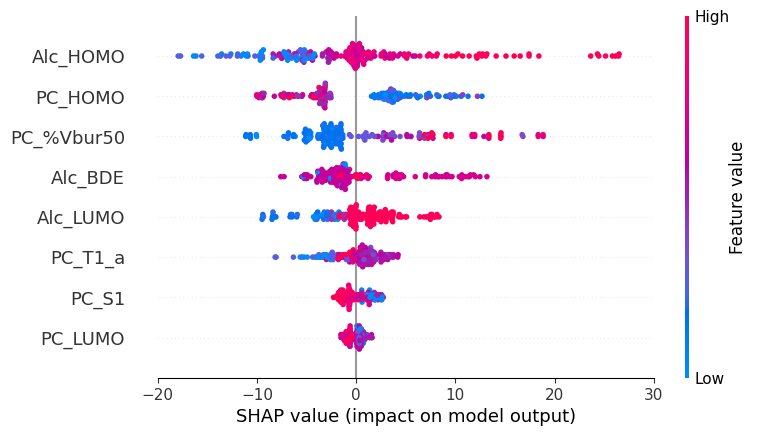

In [5]:
fig = plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.xlim(-20, 30)
plt.show()
fig.savefig('SHAP/beeswarm.pdf')

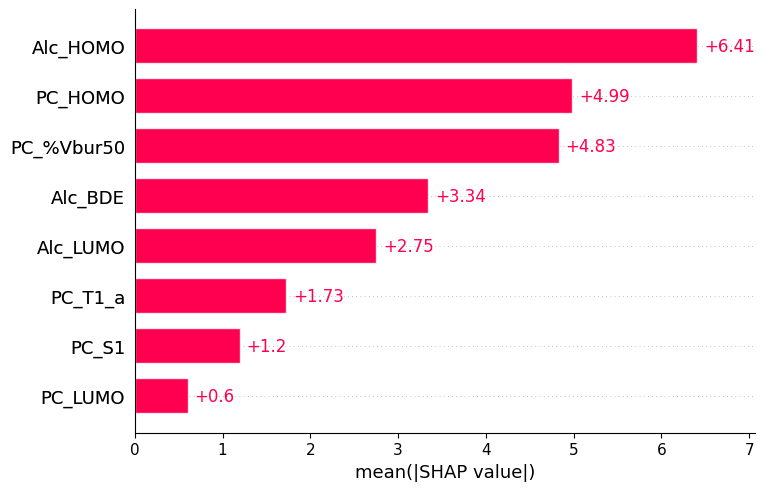

In [6]:
fig = plt.figure()
shap.plots.bar(shap_values, show=False, max_display=20)
plt.show()
fig.savefig('SHAP/bar.pdf')